In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
import shap

print(shap.__version__)

0.49.1


In [3]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
from pathlib import Path

# Portable data path. The original notebooks hardcoded Windows-style separators,
# which fail on macOS and Linux -- and in notebook 03 the path string was not a
# raw string, so the separators doubled as invalid escape sequences (a
# SyntaxWarning on Python 3.12+).
DATA_DIR = Path(os.environ.get("AGRIVISION_DATA", "data")) / "CropYield"

In [4]:
model = joblib.load("yield_prediction_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [5]:
df = pd.read_csv(DATA_DIR / "yield_df.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
from sklearn.preprocessing import LabelEncoder

# Must mirror notebook 03's encoding exactly, including column names, or the
# explainer is fed a different feature layout than the model was trained on.
area_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["Area_enc"] = area_encoder.fit_transform(df["Area"])
df["Item_enc"] = item_encoder.fit_transform(df["Item"])

In [7]:
TARGET = "hg/ha_yield"

TREE_FEATURES = [
    "Area_enc",
    "Item_enc",
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp",
]

X = df[TREE_FEATURES]
y = df[TARGET]

In [8]:
# Same temporal split as notebook 03 so the explained rows are genuinely
# held out from the model being explained.
SPLIT_YEAR = int(df["Year"].quantile(0.8))

train_mask = df["Year"] <= SPLIT_YEAR
test_mask = df["Year"] > SPLIT_YEAR

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Split at year {SPLIT_YEAR}  |  train={X_train.shape}  test={X_test.shape}")

Split at year 2009  |  train=(23233, 6)  test=(5009, 6)


In [9]:
X_sample = X_test.sample(n=500, random_state=42)

explainer = shap.Explainer(model)

# check_additivity left at its default. Disabling it silences SHAP's own
# verification that the attributions sum back to the model output, which is the
# main guard against explaining a model with a mismatched feature layout.
shap_values = explainer(X_sample)

print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(500, 6)


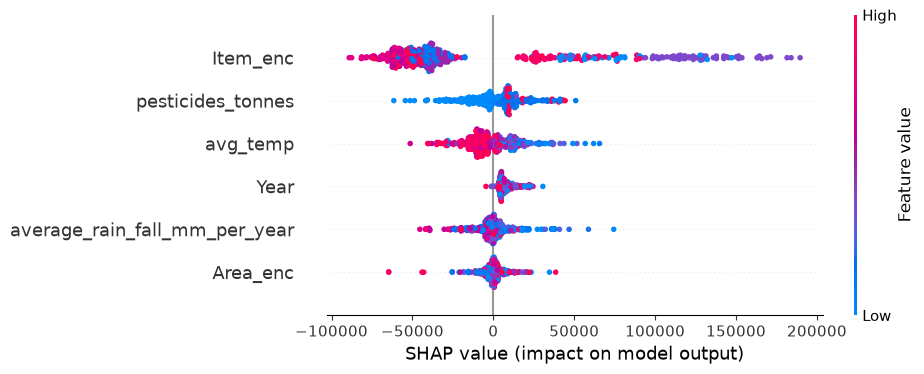

In [10]:
# SHAP Beeswarm Plot
shap.plots.beeswarm(
    shap_values,
    max_display=6,
    show=False
)

plt.savefig(
    "SHAP_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

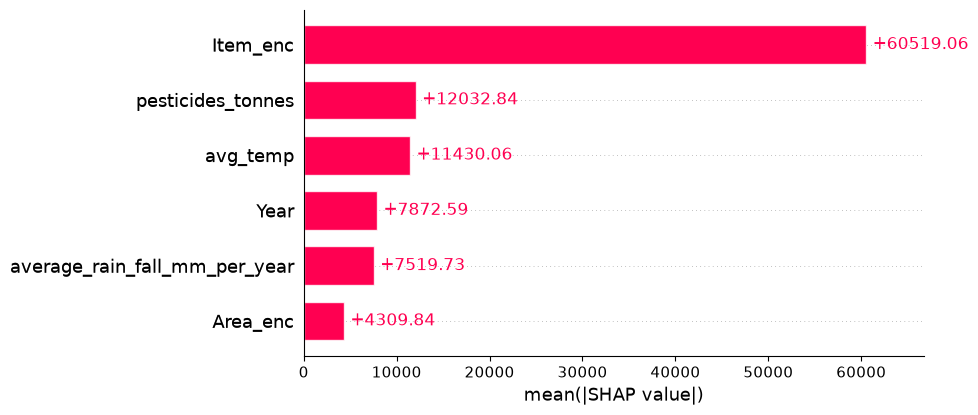

In [11]:
# SHAP Feature Importance Bar Plot

shap.plots.bar(
    shap_values,
    max_display=6,
    show=False
)

plt.savefig(
    "SHAP_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [12]:
# SHAP Waterfall Plot
import numpy as np

predictions = model.predict(X_sample)

highest_index = np.argmax(predictions)

print("Highest Predicted Yield:", predictions[highest_index])

Highest Predicted Yield: 435428.4166666667


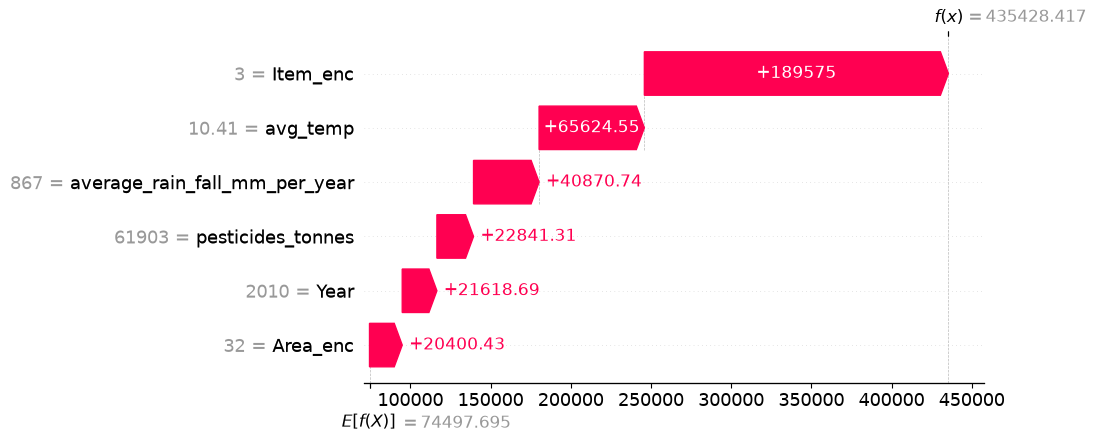

In [13]:
shap.plots.waterfall(
    shap_values[highest_index],
    show=False
)

plt.savefig(
    "SHAP_Waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Summary

1. The saved Random Forest crop yield prediction model was loaded for explainability analysis.

2. SHAP (SHapley Additive exPlanations) was used to interpret the model's predictions.

3. A SHAP Explainer was created to calculate feature contributions for prediction outcomes.

4. A SHAP Beeswarm Plot was generated to visualize both the magnitude and direction of each feature's impact on crop yield predictions.

5. A SHAP Global Feature Importance Bar Plot ranked all input features according to their overall contribution to the model.

6. A SHAP Waterfall Plot was generated for an individual sample to explain how each feature influenced a specific crop yield prediction.

7. The Explainable AI analysis improved the transparency and interpretability of the Random Forest model, making its predictions easier to understand and validate.